# 04 — SAE v1 full training (v2, robust)

**Tuần 4** — Đồ án SAE+LOF, Colab Pro + Drive persistence

**v2 fixes:**
- RNG state serialization đúng kiểu (torch.uint8 CPU)
- Defensive mkdir trước mọi write
- Reload state từ CSV nếu kernel restart (không phụ thuộc biến memory)
- Cell cleanup sẵn sàng cho trường hợp checkpoint corrupted

## Resume rules

Mỗi phiên Colab mới → chạy lại **cell 1-7** (Phần A setup) → rồi chạy cell đang dở.
- Các cell **train** (8, 15) có done-flag → skip run đã xong.
- Các cell **eval** (9, 16) có CSV cache → skip nếu file tồn tại.
- Các cell **viz/aggregate** (10-14, 17-22) đều idempotent.

Nếu checkpoint bị corrupted (TypeError RNG, corrupted pickle…) → chạy **cell 0.5** để cleanup.

# PHẦN A — Setup (cell 1-7)

### Cell 1 — Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/sae-lof-ids-pi5'
import os
assert os.path.isdir(DRIVE_ROOT), f'Không thấy {DRIVE_ROOT}'
print(f'✓ Drive root: {DRIVE_ROOT}')
print(f'  Contents: {sorted(os.listdir(DRIVE_ROOT))}')

Mounted at /content/drive
✓ Drive root: /content/drive/MyDrive/sae-lof-ids-pi5
  Contents: ['checkpoints', 'configs', 'data', 'figs', 'logs', 'notebooks', 'results', 'src']


### Cell 2 — GPU check

In [2]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA: True
Device: NVIDIA A100-SXM4-40GB
VRAM  : 42.4 GB


### Cell 3 — Cache parquet local

In [3]:
import shutil, time
from pathlib import Path

LOCAL_CACHE = Path('/content/local_cache')
LOCAL_CACHE.mkdir(exist_ok=True)
DRIVE_DATA = Path(DRIVE_ROOT) / 'data' / 'processed'

for fname in ['train_benign.parquet', 'val.parquet',
              'scaler_benign.pkl', 'label_encoder_8.pkl', 'label_encoder_34.pkl']:
    src, dst = DRIVE_DATA / fname, LOCAL_CACHE / fname
    if not src.exists():
        print(f'⚠ MISSING: {src}'); continue
    if dst.exists() and dst.stat().st_size == src.stat().st_size:
        print(f'  [cached] {fname}')
    else:
        t0 = time.time()
        shutil.copy2(src, dst)
        print(f'  [copied] {fname} ({dst.stat().st_size/1e6:.1f} MB, {time.time()-t0:.1f}s)')

  [copied] train_benign.parquet (53.2 MB, 6.8s)
  [copied] val.parquet (182.6 MB, 14.1s)
  [copied] scaler_benign.pkl (0.0 MB, 0.9s)
  [copied] label_encoder_8.pkl (0.0 MB, 1.2s)
  [copied] label_encoder_34.pkl (0.0 MB, 0.7s)


### Cell 4 — Import modules (force reload)

In [4]:
import sys
SRC_DIR = Path(DRIVE_ROOT) / 'src'
assert SRC_DIR.exists()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Force reload modules (nếu re-run trong cùng session)
for mod in list(sys.modules):
    if mod.startswith('sae_'):
        del sys.modules[mod]

from sae_model import SparseAutoencoder
from sae_losses import sae_loss
from sae_dataset import make_dataloaders
from sae_train_v1 import TrainConfigV1, train_with_resume
print('✓ Modules imported')

✓ Modules imported


### Cell 5 — Output dirs (defensive mkdir)

In [5]:
PROJ_ROOT  = Path(DRIVE_ROOT)
CKPT_DIR   = PROJ_ROOT / 'checkpoints' / 'week4'
LOG_DIR    = PROJ_ROOT / 'logs'        / 'week4'
FIG_DIR    = PROJ_ROOT / 'figs'        / 'week4'
RESULT_DIR = PROJ_ROOT / 'results'     / 'week4'
for d in (CKPT_DIR, LOG_DIR, FIG_DIR, RESULT_DIR):
    d.mkdir(parents=True, exist_ok=True)
    print(f'  {d} — {"exists" if d.exists() else "FAIL"}')

  /content/drive/MyDrive/sae-lof-ids-pi5/checkpoints/week4 — exists
  /content/drive/MyDrive/sae-lof-ids-pi5/logs/week4 — exists
  /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4 — exists
  /content/drive/MyDrive/sae-lof-ids-pi5/results/week4 — exists


### Cell 6 — Load tuned config

In [6]:
import yaml
with open(PROJ_ROOT / 'configs' / 'sae_v0_tuned.yaml') as f:
    w3 = yaml.safe_load(f)

GRID_RHOS  = [0.01, 0.05, 0.10, 0.20]
GRID_BETAS = [1.0, 3.0, 10.0]
SEEDS      = [0, 1, 42, 123, 2026]

BASE = {
    'train_path': str(LOCAL_CACHE / 'train_benign.parquet'),
    'val_path'  : str(LOCAL_CACHE / 'val.parquet'),
    'benign_label': int(w3['data']['benign_label']),
    'max_train_samples': None, 'max_val_samples': None,
    'input_dim'  : w3['model']['input_dim'],
    'hidden_dims': tuple(w3['model']['hidden_dims']),
    'latent_dim' : w3['model']['latent_dim'],
    'lr'         : w3['optim']['lr'],
    'batch_size' : w3['optim']['batch_size'],
    'max_epochs' : w3['optim']['max_epochs'],
    'patience'   : w3['optim']['patience'],
    'num_workers': 4, 'device': 'auto',
    'ckpt_dir': str(CKPT_DIR), 'log_dir': str(LOG_DIR),
    'verbose_every': 5,
}
print(f'Grid: {len(GRID_RHOS)*len(GRID_BETAS)} combo')
print(f'Seeds: {SEEDS}')
print(f'Train path: {BASE["train_path"]}')

Grid: 12 combo
Seeds: [0, 1, 42, 123, 2026]
Train path: /content/local_cache/train_benign.parquet


### Cell 7 — Sanity check

In [7]:
import time, gc

_t = time.time()
_tl, _vl, _nf = make_dataloaders(
    train_path=BASE['train_path'], val_path=BASE['val_path'],
    batch_size=BASE['batch_size'],
    max_train_samples=10_000, max_val_samples=5_000,
    benign_label=BASE['benign_label'], num_workers=2, seed=0,
)
print(f'Loaders ready in {time.time()-_t:.1f}s — n_feat={_nf}')

_dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_m = SparseAutoencoder(input_dim=_nf, hidden_dims=(32,16), latent_dim=8).to(_dev)
print(f'Model on {_dev}: {_m.count_parameters():,} params')

_x = next(iter(_tl)).to(_dev)
_xh, _z = _m(_x)
_loss, _comp = sae_loss(_x, _xh, _z, rho=0.05, beta=3.0)
print(f'  batch {tuple(_x.shape)}  latent {tuple(_z.shape)}  range [{_z.min():.3f},{_z.max():.3f}]')
print(f'  MSE={_comp["mse"]:.4f}  KL={_comp["kl"]:.4f}  Total={_comp["total"]:.4f}')
print(f'  ρ̂: mean={_comp["rho_hat_mean"]:.3f} min={_comp["rho_hat_min"]:.3f} max={_comp["rho_hat_max"]:.3f}')
print('\n✓ Sanity PASSED')

del _tl, _vl, _m, _x, _xh, _z, _loss, _comp
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

BenignFlowDataset(train_benign.parquet): 10,000 rows × 46 features
BenignFlowDataset(val.parquet): 5,000 rows × 46 features
Loaders ready in 0.8s — n_feat=46
Model on cuda: 4,374 params
  batch (256, 46)  latent (256, 8)  range [0.000,1.000]
  MSE=1.4890  KL=6.1520  Total=19.9450
  ρ̂: mean=0.608 min=0.317 max=0.783

✓ Sanity PASSED


### Cell 7.5 — [OPTIONAL] Cleanup corrupted checkpoints

**Chỉ chạy khi cần** — ví dụ sau khi update code `sae_train_v1.py` với format RNG state mới, các `_last.pt` cũ không còn tương thích.

Logic:
- Giữ nguyên `.done` flags và `_best.pt` (đã hoàn thành, không cần train lại)
- Xoá `_last.pt`, `_state.json`, `_history.json` của combo CHƯA `.done`

**Bỏ qua cell này (không chạy)** nếu đang chạy lần đầu từ scratch.

In [ ]:
# UNCOMMENT để chạy cleanup
# done_flags = set(f.stem for f in CKPT_DIR.glob('*.done'))
# print(f'Found {len(done_flags)} .done flags (will be preserved)')
#
# n_removed = 0
# for pattern_dir, exts in [(CKPT_DIR, ['_last.pt','_state.json']),
#                           (LOG_DIR, ['_history.json'])]:
#     for f in pattern_dir.iterdir():
#         if not f.is_file(): continue
#         matched_ext = next((e for e in exts if f.name.endswith(e)), None)
#         if matched_ext is None: continue
#         run_name = f.name[:-len(matched_ext)]
#         if run_name in done_flags:
#             continue  # giữ lại
#         f.unlink(); n_removed += 1
#
# print(f'Removed {n_removed} files from unfinished runs')
print('Cell 7.5 skipped (uncomment to cleanup corrupted state)')

# PHẦN B — Grid 4×3 (cell 8-14)

Mỗi combo có done-flag. Chạy lại cell 8 bất kỳ lúc nào đều an toàn.

### Cell 8 — Grid training (12 combo × seed 0)

In [8]:
import itertools

GRID_COMBOS = list(itertools.product(GRID_RHOS, GRID_BETAS))
print(f'=== GRID: {len(GRID_COMBOS)} combo ===\n')

grid_summaries = []
t0 = time.time()

for i, (rho, beta) in enumerate(GRID_COMBOS, 1):
    run_name = f'sae_v1_rho={rho}_beta={beta}_seed=0'
    print(f'\n--- [{i}/{len(GRID_COMBOS)}] {run_name} ---')
    cfg = TrainConfigV1(rho=rho, beta=beta, seed=0, run_name=run_name, **BASE)
    summary = train_with_resume(cfg)
    grid_summaries.append({'rho': rho, 'beta': beta, 'seed': 0, **summary})

    if summary.get('status') != 'skipped_done':
        print(f'  → best_val_mse={summary["best_val_mse"]:.5f} @ ep {summary["best_epoch"]}')
    elapsed = time.time() - t0
    remaining = (elapsed/i) * (len(GRID_COMBOS) - i)
    print(f'  Elapsed {elapsed/60:.1f} min, ~{remaining/60:.1f} min remaining')

print(f'\n=== GRID DONE in {(time.time()-t0)/60:.1f} min ===')

=== GRID: 12 combo ===


--- [1/12] sae_v1_rho=0.01_beta=1.0_seed=0 ---
[sae_v1_rho=0.01_beta=1.0_seed=0] device=cuda  rho=0.01  beta=1.0  seed=0
BenignFlowDataset(train_benign.parquet): 878,556 rows × 46 features
BenignFlowDataset(val.parquet): 109,820 rows × 46 features
[FRESH] seed=0
  ep   0/200  train MSE=0.46345  val MSE=0.28223  ρ̂=0.0125  ✓ BEST
  ep   1/200  train MSE=0.24738  val MSE=0.20086  ρ̂=0.0116  ✓ BEST
  ep   2/200  train MSE=0.18981  val MSE=0.16168  ρ̂=0.0113  ✓ BEST
  ep   3/200  train MSE=0.16197  val MSE=0.13856  ρ̂=0.0111  ✓ BEST
  ep   4/200  train MSE=0.14147  val MSE=0.11763  ρ̂=0.0111  ✓ BEST
  ep   5/200  train MSE=0.12504  val MSE=0.10309  ρ̂=0.0109  ✓ BEST
  ep   6/200  train MSE=0.11394  val MSE=0.09528  ρ̂=0.0108  ✓ BEST
  ep   7/200  train MSE=0.10707  val MSE=0.08604  ρ̂=0.0107  ✓ BEST
  ep   8/200  train MSE=0.10070  val MSE=0.08093  ρ̂=0.0107  ✓ BEST
  ep   9/200  train MSE=0.09464  val MSE=0.07691  ρ̂=0.0106  ✓ BEST
  ep  10/200  train MSE=0.09045 

### Cell 9 — Eval AUC

Robust: nếu `grid_summaries` mất (kernel restart), reload từ checkpoint files trong Drive.

In [9]:
import numpy as np
import pandas as pd
import json
from sklearn.metrics import roc_auc_score, roc_curve

GRID_CSV = RESULT_DIR / 'week4_grid_extended.csv'
GRID_CSV.parent.mkdir(parents=True, exist_ok=True)

# Reload grid_summaries từ state files nếu biến không còn trong memory
try:
    _ = grid_summaries
    print(f'Using grid_summaries from memory ({len(grid_summaries)} runs)')
except NameError:
    print('grid_summaries not in memory — reloading from Drive state files')
    grid_summaries = []
    for rho in GRID_RHOS:
        for beta in GRID_BETAS:
            run_name = f'sae_v1_rho={rho}_beta={beta}_seed=0'
            state_file = CKPT_DIR / f'{run_name}_state.json'
            if not state_file.exists():
                print(f'  ⚠ missing: {run_name}'); continue
            with open(state_file) as f:
                s = json.load(f)
            grid_summaries.append({
                'rho': rho, 'beta': beta, 'seed': 0,
                'run_name': run_name,
                'best_val_mse': s.get('best_val_mse'),
                'best_epoch'  : s.get('best_epoch'),
                'total_epochs_run': s.get('epoch', 0) + 1,
                'total_time_s': s.get('total_time_s', 0),
                'model_params': s.get('model_params', 4374),
            })
    print(f'  Reloaded {len(grid_summaries)} runs')

if GRID_CSV.exists():
    grid_df = pd.read_csv(GRID_CSV)
    print(f'[SKIP] {GRID_CSV} already exists')
else:
    print('\nLoading val data...')
    val_df = pd.read_parquet(BASE['val_path'])
    label_col = next((c for c in ['y8','y_bin','y34','Label','label'] if c in val_df.columns), None)
    assert label_col, f'Columns: {list(val_df.columns)}'
    ALL_LABEL = {'y_bin','y8','y34','Label','label'}
    feat_cols = [c for c in val_df.columns if c not in ALL_LABEL]
    print(f'  label_col={label_col}, n_feat={len(feat_cols)}')

    N_EVAL = 100_000
    benign = val_df[val_df[label_col] == BASE['benign_label']].sample(N_EVAL, random_state=0)
    attack = val_df[val_df[label_col] != BASE['benign_label']].sample(N_EVAL, random_state=0)
    X_b = torch.from_numpy(benign[feat_cols].to_numpy(np.float32))
    X_a = torch.from_numpy(attack[feat_cols].to_numpy(np.float32))
    del val_df, benign, attack

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def recon_mse(model, X, bs=4096):
        model.eval(); errs = []
        with torch.no_grad():
            for i in range(0, len(X), bs):
                xb = X[i:i+bs].to(device)
                xh, _ = model(xb)
                errs.append(((xh-xb)**2).mean(dim=1).cpu().numpy())
        return np.concatenate(errs)

    rows = []
    for i, s in enumerate(grid_summaries, 1):
        run = s['run_name'] if 'run_name' in s else f"sae_v1_rho={s['rho']}_beta={s['beta']}_seed=0"
        best_ckpt = CKPT_DIR / f'{run}_best.pt'
        ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
        m = SparseAutoencoder(input_dim=len(feat_cols), hidden_dims=(32,16), latent_dim=8).to(device)
        m.load_state_dict(ckpt['model_state_dict'])

        err_b = recon_mse(m, X_b)
        err_a = recon_mse(m, X_a)
        y_true  = np.concatenate([np.zeros(len(err_b)), np.ones(len(err_a))])
        y_score = np.concatenate([err_b, err_a])
        auc = roc_auc_score(y_true, y_score)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        idx = np.searchsorted(tpr, 0.95)
        fpr95 = fpr[min(idx, len(fpr)-1)]

        rows.append({
            'rho': s['rho'], 'beta': s['beta'], 'seed': 0,
            'best_val_mse': s['best_val_mse'],
            'best_epoch': s['best_epoch'],
            'epochs_run': s['total_epochs_run'],
            'final_rho_hat_mean': float(ckpt.get('val_rho_hat_mean', np.nan)),
            'rho_hat_dev': abs(float(ckpt.get('val_rho_hat_mean', 0)) - s['rho']),
            'auc_recon': float(auc),
            'fpr_at_tpr95': float(fpr95),
            'recon_err_benign_median': float(np.median(err_b)),
            'recon_err_attack_median': float(np.median(err_a)),
            'time_s': s['total_time_s'],
            'model_params': s['model_params'],
        })
        print(f'  [{i}/{len(grid_summaries)}] rho={s["rho"]} beta={s["beta"]}  AUC={auc:.5f}  FPR@95={fpr95:.4f}')

    grid_df = pd.DataFrame(rows)
    grid_df.to_csv(GRID_CSV, index=False)
    print(f'\n✓ Saved {GRID_CSV}')
    del X_b, X_a
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print('\n=== GRID RESULT (sort by AUC) ===')
print(grid_df.sort_values('auc_recon', ascending=False)[
    ['rho','beta','auc_recon','best_val_mse','fpr_at_tpr95','rho_hat_dev','epochs_run']
].to_string(index=False, float_format='%.5f'))

Using grid_summaries from memory (12 runs)

Loading val data...
  label_col=y8, n_feat=46
  [1/12] rho=0.01 beta=1.0  AUC=0.99433  FPR@95=0.0085
  [2/12] rho=0.01 beta=3.0  AUC=0.99547  FPR@95=0.0049
  [3/12] rho=0.01 beta=10.0  AUC=0.99450  FPR@95=0.0101
  [4/12] rho=0.05 beta=1.0  AUC=0.99583  FPR@95=0.0042
  [5/12] rho=0.05 beta=3.0  AUC=0.99532  FPR@95=0.0055
  [6/12] rho=0.05 beta=10.0  AUC=0.99314  FPR@95=0.0114
  [7/12] rho=0.1 beta=1.0  AUC=0.99007  FPR@95=0.0181
  [8/12] rho=0.1 beta=3.0  AUC=0.99467  FPR@95=0.0038
  [9/12] rho=0.1 beta=10.0  AUC=0.99553  FPR@95=0.0022
  [10/12] rho=0.2 beta=1.0  AUC=0.99491  FPR@95=0.0020
  [11/12] rho=0.2 beta=3.0  AUC=0.99367  FPR@95=0.0060
  [12/12] rho=0.2 beta=10.0  AUC=0.98898  FPR@95=0.0410

✓ Saved /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_grid_extended.csv

=== GRID RESULT (sort by AUC) ===
    rho     beta  auc_recon  best_val_mse  fpr_at_tpr95  rho_hat_dev  epochs_run
0.05000  1.00000    0.99583       0.02202      

### Cell 10 — Heatmap 4×3

Saved /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_grid_heatmap.png


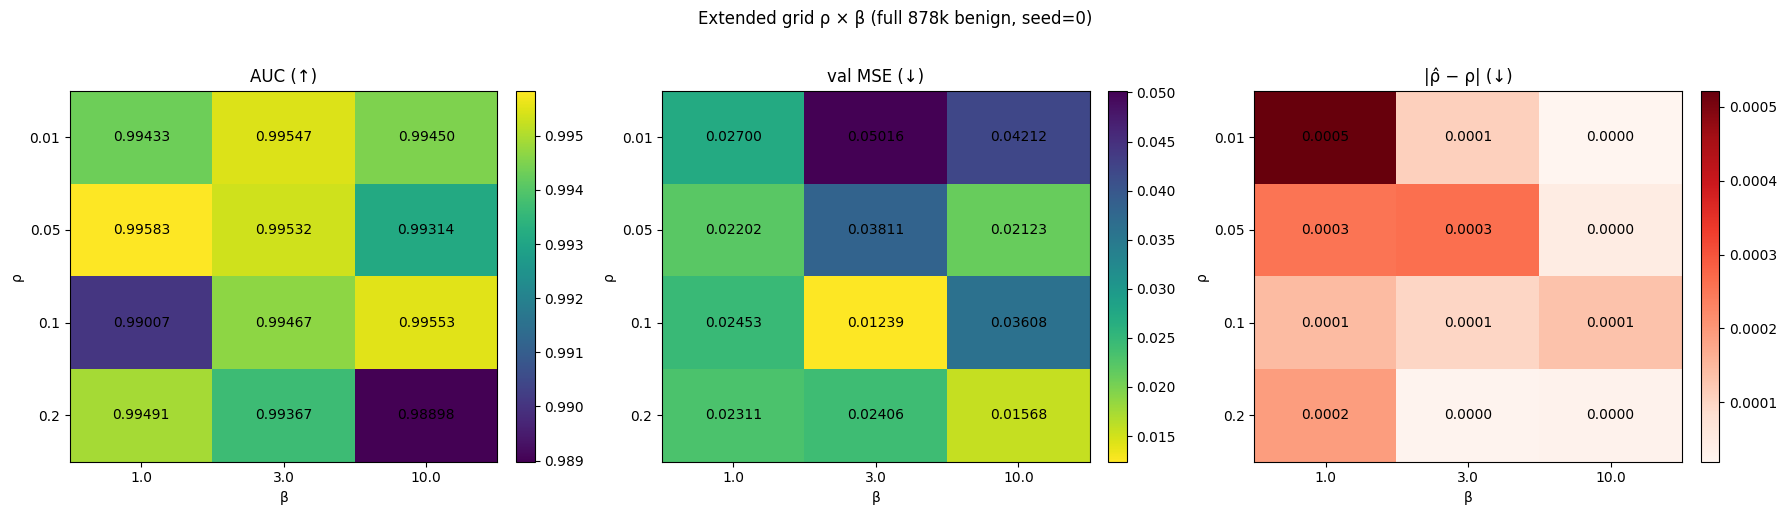

In [10]:
import matplotlib.pyplot as plt

FIG_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def draw(ax, piv, title, cmap, fmt):
    im = ax.imshow(piv.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel('β'); ax.set_ylabel('ρ'); ax.set_title(title)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f'{piv.values[i,j]:{fmt}}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

draw(axes[0], grid_df.pivot(index='rho', columns='beta', values='auc_recon'),
     'AUC (↑)', 'viridis', '.5f')
draw(axes[1], grid_df.pivot(index='rho', columns='beta', values='best_val_mse'),
     'val MSE (↓)', 'viridis_r', '.5f')
draw(axes[2], grid_df.pivot(index='rho', columns='beta', values='rho_hat_dev'),
     '|ρ̂ − ρ| (↓)', 'Reds', '.4f')

plt.suptitle('Extended grid ρ × β (full 878k benign, seed=0)', y=1.02)
plt.tight_layout()
out = FIG_DIR / '04_grid_heatmap.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

### Cell 11 — Pick top-2 (persist sang JSON để không phụ thuộc memory)

In [11]:
TOP_JSON = RESULT_DIR / 'week4_top_configs.json'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

ok = grid_df[grid_df['rho_hat_dev'] < 0.02].sort_values('auc_recon', ascending=False)
if len(ok) < 2:
    ok = grid_df[grid_df['rho_hat_dev'] < 0.05].sort_values('auc_recon', ascending=False)

TOP_CONFIGS_PICKED = [
    {'rho': float(ok.iloc[0]['rho']), 'beta': float(ok.iloc[0]['beta']),
     'rank': 1, 'auc': float(ok.iloc[0]['auc_recon'])},
    {'rho': float(ok.iloc[1]['rho']), 'beta': float(ok.iloc[1]['beta']),
     'rank': 2, 'auc': float(ok.iloc[1]['auc_recon'])},
]
with open(TOP_JSON, 'w') as f:
    json.dump(TOP_CONFIGS_PICKED, f, indent=2)
print(f'✓ Saved {TOP_JSON}')
for c in TOP_CONFIGS_PICKED:
    print(f"  Rank {c['rank']}: ρ={c['rho']} β={c['beta']}  AUC={c['auc']:.5f}")

✓ Saved /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_top_configs.json
  Rank 1: ρ=0.05 β=1.0  AUC=0.99583
  Rank 2: ρ=0.1 β=10.0  AUC=0.99553


### Cell 12 — Learning curves top-1

Saved /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_learning_curves_top1.png


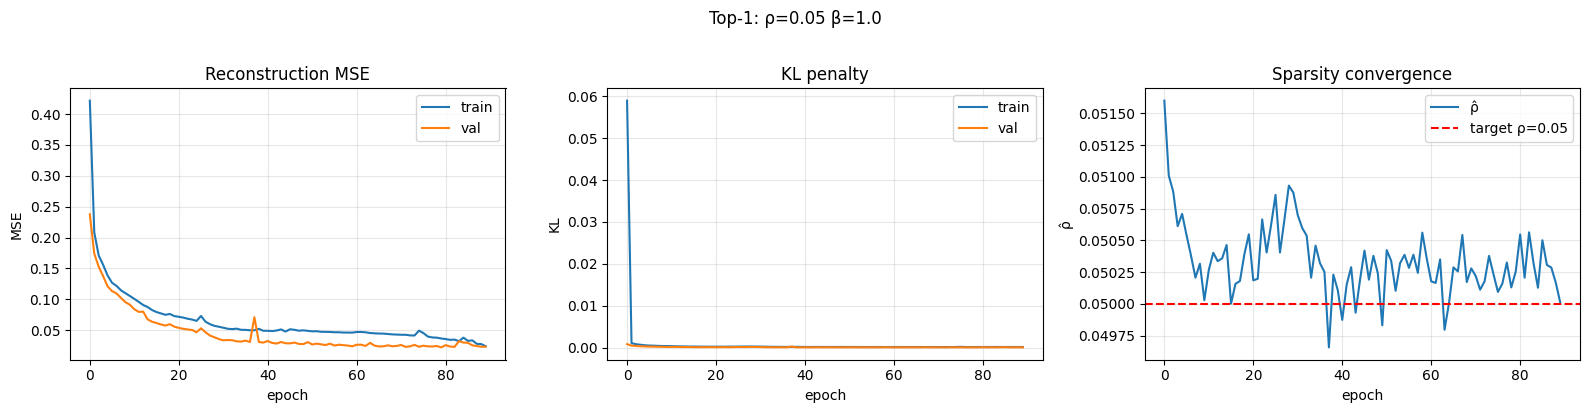

In [12]:
# Reload top configs từ JSON (không phụ thuộc memory)
with open(TOP_JSON) as f:
    TOP_CONFIGS_PICKED = json.load(f)
top1 = TOP_CONFIGS_PICKED[0]

top1_run = f"sae_v1_rho={top1['rho']}_beta={top1['beta']}_seed=0"
hist_file = LOG_DIR / f'{top1_run}_history.json'
with open(hist_file) as f:
    hist = json.load(f)

eps = [h['epoch'] for h in hist]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(eps, [h['train_mse'] for h in hist], label='train')
axes[0].plot(eps, [h['val_mse']   for h in hist], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE'); axes[0].legend()
axes[0].grid(alpha=.3); axes[0].set_title('Reconstruction MSE')

axes[1].plot(eps, [h['train_kl'] for h in hist], label='train')
axes[1].plot(eps, [h['val_kl']   for h in hist], label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('KL'); axes[1].legend()
axes[1].grid(alpha=.3); axes[1].set_title('KL penalty')

axes[2].plot(eps, [h['val_rho_hat_mean'] for h in hist], label='ρ̂')
axes[2].axhline(top1['rho'], color='red', linestyle='--', label=f'target ρ={top1["rho"]}')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('ρ̂'); axes[2].legend()
axes[2].grid(alpha=.3); axes[2].set_title('Sparsity convergence')

plt.suptitle(f'Top-1: ρ={top1["rho"]} β={top1["beta"]}', y=1.02)
plt.tight_layout()
out = FIG_DIR / '04_learning_curves_top1.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

### Cell 13 — Cleanup memory trước Phần C

In [13]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f'GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated')
print('✓ Ready for Phần C')

GPU: 0.02 GB allocated
✓ Ready for Phần C


### Cell 14 — Checklist Phần B

In [14]:
expected = {
    'Grid CSV'      : GRID_CSV,
    'Top JSON'      : TOP_JSON,
    'Heatmap'       : FIG_DIR / '04_grid_heatmap.png',
    'LR curves'     : FIG_DIR / '04_learning_curves_top1.png',
}
for rho in GRID_RHOS:
    for beta in GRID_BETAS:
        expected[f'ckpt ρ={rho} β={beta}'] = CKPT_DIR / f'sae_v1_rho={rho}_beta={beta}_seed=0_best.pt'
        expected[f'done ρ={rho} β={beta}'] = CKPT_DIR / f'sae_v1_rho={rho}_beta={beta}_seed=0.done'

ok, miss = [], []
for k, v in expected.items():
    (ok if v.exists() else miss).append((k, v))

print(f'✓ {len(ok)}/{len(expected)} artifacts present')
if miss:
    print(f'\n⚠ Missing {len(miss)}:')
    for k, v in miss: print(f'  {k}: {v}')

✓ 28/28 artifacts present


# PHẦN C — Multi-seed top-2 (cell 15-17)

### Cell 15 — Multi-seed training

In [15]:
with open(TOP_JSON) as f:
    TOP_CONFIGS_PICKED = json.load(f)

ms_runs = [(c['rho'], c['beta'], s) for c in TOP_CONFIGS_PICKED for s in SEEDS]
print(f'=== MULTI-SEED: {len(ms_runs)} runs ===\n')

ms_summaries = []
t0 = time.time()
for i, (rho, beta, seed) in enumerate(ms_runs, 1):
    run_name = f'sae_v1_rho={rho}_beta={beta}_seed={seed}'
    print(f'\n--- [{i}/{len(ms_runs)}] {run_name} ---')
    cfg = TrainConfigV1(rho=rho, beta=beta, seed=seed, run_name=run_name, **BASE)
    summary = train_with_resume(cfg)
    ms_summaries.append({'rho': rho, 'beta': beta, 'seed': seed, **summary})
    elapsed = time.time() - t0
    if summary.get('status') != 'skipped_done':
        print(f'  → best_val_mse={summary["best_val_mse"]:.5f}')
    print(f'  Elapsed {elapsed/60:.1f} min')

print(f'\n=== DONE in {(time.time()-t0)/60:.1f} min ===')

=== MULTI-SEED: 10 runs ===


--- [1/10] sae_v1_rho=0.05_beta=1.0_seed=0 ---
[SKIP] sae_v1_rho=0.05_beta=1.0_seed=0 already completed
  Elapsed 0.0 min

--- [2/10] sae_v1_rho=0.05_beta=1.0_seed=1 ---
[sae_v1_rho=0.05_beta=1.0_seed=1] device=cuda  rho=0.05  beta=1.0  seed=1
BenignFlowDataset(train_benign.parquet): 878,556 rows × 46 features
BenignFlowDataset(val.parquet): 109,820 rows × 46 features
[FRESH] seed=1
  ep   0/200  train MSE=0.46058  val MSE=0.27369  ρ̂=0.0518  ✓ BEST
  ep   1/200  train MSE=0.24288  val MSE=0.19249  ρ̂=0.0513  ✓ BEST
  ep   2/200  train MSE=0.18265  val MSE=0.15815  ρ̂=0.0509  ✓ BEST
  ep   3/200  train MSE=0.15443  val MSE=0.13451  ρ̂=0.0507  ✓ BEST
  ep   4/200  train MSE=0.13712  val MSE=0.12350  ρ̂=0.0506  ✓ BEST
  ep   5/200  train MSE=0.12980  val MSE=0.11946  ρ̂=0.0504  ✓ BEST
  ep   6/200  train MSE=0.12594  val MSE=0.11618  ρ̂=0.0504  ✓ BEST
  ep   7/200  train MSE=0.12189  val MSE=0.11181  ρ̂=0.0507  ✓ BEST
  ep   8/200  train MSE=0.11594  val MSE

### Cell 16 — Eval multi-seed (robust reload)

In [16]:
MS_CSV = RESULT_DIR / 'week4_multiseed.csv'
MS_CSV.parent.mkdir(parents=True, exist_ok=True)

with open(TOP_JSON) as f:
    TOP_CONFIGS_PICKED = json.load(f)

# Reload ms_summaries nếu memory mất
try:
    _ = ms_summaries
except NameError:
    print('ms_summaries not in memory — reloading from state files')
    ms_summaries = []
    for c in TOP_CONFIGS_PICKED:
        for seed in SEEDS:
            run = f"sae_v1_rho={c['rho']}_beta={c['beta']}_seed={seed}"
            sf = CKPT_DIR / f'{run}_state.json'
            if not sf.exists():
                print(f'  ⚠ missing: {run}'); continue
            with open(sf) as f:
                s = json.load(f)
            ms_summaries.append({
                'rho': c['rho'], 'beta': c['beta'], 'seed': seed,
                'run_name': run,
                'best_val_mse': s.get('best_val_mse'),
                'best_epoch': s.get('best_epoch'),
                'total_epochs_run': s.get('epoch', 0) + 1,
                'total_time_s': s.get('total_time_s', 0),
            })

if MS_CSV.exists():
    ms_df = pd.read_csv(MS_CSV)
    print(f'[SKIP] {MS_CSV}')
else:
    val_df = pd.read_parquet(BASE['val_path'])
    label_col = next((c for c in ['y8','y_bin','y34','Label','label'] if c in val_df.columns), None)
    ALL_LABEL = {'y_bin','y8','y34','Label','label'}
    feat_cols = [c for c in val_df.columns if c not in ALL_LABEL]

    N_EVAL = 100_000
    benign = val_df[val_df[label_col] == BASE['benign_label']].sample(N_EVAL, random_state=0)
    attack = val_df[val_df[label_col] != BASE['benign_label']].sample(N_EVAL, random_state=0)
    X_b = torch.from_numpy(benign[feat_cols].to_numpy(np.float32))
    X_a = torch.from_numpy(attack[feat_cols].to_numpy(np.float32))
    del val_df, benign, attack

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def recon_mse(model, X, bs=4096):
        model.eval(); errs = []
        with torch.no_grad():
            for i in range(0, len(X), bs):
                xb = X[i:i+bs].to(device)
                xh, _ = model(xb)
                errs.append(((xh-xb)**2).mean(dim=1).cpu().numpy())
        return np.concatenate(errs)

    rows = []
    for i, s in enumerate(ms_summaries, 1):
        run = s.get('run_name', f"sae_v1_rho={s['rho']}_beta={s['beta']}_seed={s['seed']}")
        ckpt = torch.load(CKPT_DIR / f'{run}_best.pt', map_location=device, weights_only=False)
        m = SparseAutoencoder(input_dim=len(feat_cols), hidden_dims=(32,16), latent_dim=8).to(device)
        m.load_state_dict(ckpt['model_state_dict'])

        err_b = recon_mse(m, X_b); err_a = recon_mse(m, X_a)
        y_true  = np.concatenate([np.zeros(len(err_b)), np.ones(len(err_a))])
        y_score = np.concatenate([err_b, err_a])
        auc = float(roc_auc_score(y_true, y_score))
        fpr, tpr, _ = roc_curve(y_true, y_score)
        idx = np.searchsorted(tpr, 0.95)
        fpr95 = float(fpr[min(idx, len(fpr)-1)])

        rows.append({
            'rho': s['rho'], 'beta': s['beta'], 'seed': s['seed'],
            'best_val_mse': s.get('best_val_mse'),
            'best_epoch': s.get('best_epoch'),
            'epochs_run': s.get('total_epochs_run'),
            'auc_recon': auc, 'fpr_at_tpr95': fpr95,
            'time_s': s.get('total_time_s'),
        })
        print(f'  [{i}/{len(ms_summaries)}] {run}  AUC={auc:.5f}')

    ms_df = pd.DataFrame(rows)
    ms_df.to_csv(MS_CSV, index=False)
    print(f'\n✓ {MS_CSV}')
    del X_b, X_a
    if torch.cuda.is_available(): torch.cuda.empty_cache()

agg = ms_df.groupby(['rho','beta']).agg(
    auc_mean=('auc_recon','mean'),    auc_std=('auc_recon','std'),
    fpr_mean=('fpr_at_tpr95','mean'), fpr_std=('fpr_at_tpr95','std'),
    mse_mean=('best_val_mse','mean'), mse_std=('best_val_mse','std'),
).reset_index()
print('\n=== MULTI-SEED AGG (mean ± std, n=5) ===')
print(agg.to_string(index=False, float_format='%.5f'))

  [1/10] sae_v1_rho=0.05_beta=1.0_seed=0  AUC=0.99583
  [2/10] sae_v1_rho=0.05_beta=1.0_seed=1  AUC=0.99531
  [3/10] sae_v1_rho=0.05_beta=1.0_seed=42  AUC=0.99379
  [4/10] sae_v1_rho=0.05_beta=1.0_seed=123  AUC=0.99458
  [5/10] sae_v1_rho=0.05_beta=1.0_seed=2026  AUC=0.99597
  [6/10] sae_v1_rho=0.1_beta=10.0_seed=0  AUC=0.99553
  [7/10] sae_v1_rho=0.1_beta=10.0_seed=1  AUC=0.99436
  [8/10] sae_v1_rho=0.1_beta=10.0_seed=42  AUC=0.99561
  [9/10] sae_v1_rho=0.1_beta=10.0_seed=123  AUC=0.99550
  [10/10] sae_v1_rho=0.1_beta=10.0_seed=2026  AUC=0.99420

✓ /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_multiseed.csv

=== MULTI-SEED AGG (mean ± std, n=5) ===
    rho     beta  auc_mean  auc_std  fpr_mean  fpr_std  mse_mean  mse_std
0.05000  1.00000   0.99510  0.00091   0.00531  0.00517   0.03168  0.01369
0.10000 10.00000   0.99504  0.00070   0.00394  0.00256   0.02685  0.01196


### Cell 17 — Boxplot 5-seed

Saved /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_seed_boxplot.png


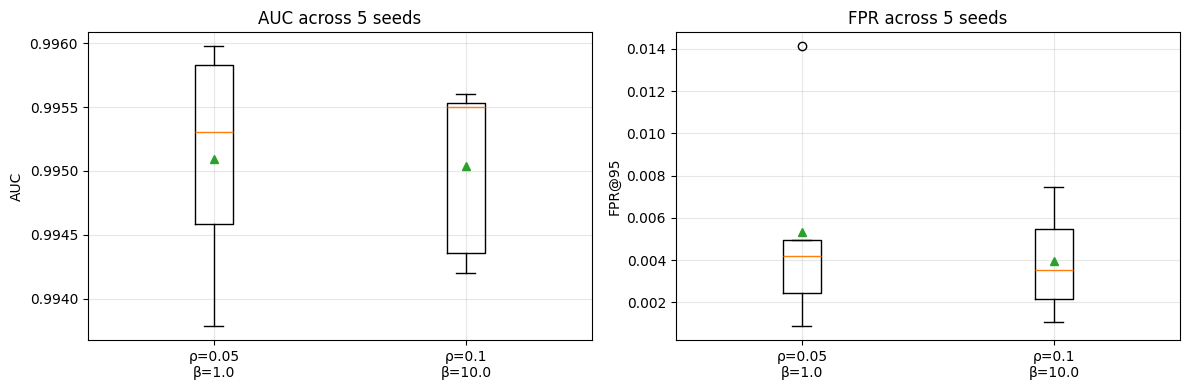

In [19]:
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

groups_auc = [ms_df[(ms_df['rho']==c['rho']) & (ms_df['beta']==c['beta'])]['auc_recon'].values
              for c in TOP_CONFIGS_PICKED]
groups_fpr = [ms_df[(ms_df['rho']==c['rho']) & (ms_df['beta']==c['beta'])]['fpr_at_tpr95'].values
              for c in TOP_CONFIGS_PICKED]
labels = [f"ρ={c['rho']}\nβ={c['beta']}" for c in TOP_CONFIGS_PICKED]

axes[0].boxplot(groups_auc, tick_labels=labels, showmeans=True)
axes[0].set_ylabel('AUC'); axes[0].set_title('AUC across 5 seeds'); axes[0].grid(alpha=.3)

axes[1].boxplot(groups_fpr, tick_labels=labels, showmeans=True)
axes[1].set_ylabel('FPR@95'); axes[1].set_title('FPR across 5 seeds'); axes[1].grid(alpha=.3)

plt.tight_layout()
out = FIG_DIR / '04_seed_boxplot.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

# PHẦN D — Latent export cho Week 5 (cell 18-22)

### Cell 18 — Extract latent z

In [20]:
with open(TOP_JSON) as f:
    TOP_CONFIGS_PICKED = json.load(f)
top1 = TOP_CONFIGS_PICKED[0]

Z_BENIGN = RESULT_DIR / 'z_benign_train_top1_seed0.npy'
Z_VAL    = RESULT_DIR / 'z_val_top1_seed0.npy'
Y_VAL_8  = RESULT_DIR / 'y_val_8class_top1_seed0.npy'
Y_VAL_34 = RESULT_DIR / 'y_val_34class_top1_seed0.npy'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

if all(p.exists() for p in [Z_BENIGN, Z_VAL]):
    print('[SKIP] Latent embeddings đã có')
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    run1 = f"sae_v1_rho={top1['rho']}_beta={top1['beta']}_seed=0"
    ckpt = torch.load(CKPT_DIR / f'{run1}_best.pt', map_location=device, weights_only=False)

    _head = pd.read_parquet(BASE['val_path']).head(1)
    ALL_LABEL = {'y_bin','y8','y34','Label','label'}
    feat_cols = [c for c in _head.columns if c not in ALL_LABEL]
    print(f'n_feat: {len(feat_cols)}')

    m = SparseAutoencoder(input_dim=len(feat_cols), hidden_dims=(32,16), latent_dim=8).to(device)
    m.load_state_dict(ckpt['model_state_dict']); m.eval()

    def encode(pq, cols, bs=8192):
        X = pd.read_parquet(pq, columns=cols).to_numpy(np.float32)
        zs = []
        with torch.no_grad():
            for i in range(0, len(X), bs):
                xb = torch.from_numpy(X[i:i+bs]).to(device)
                zs.append(m.encode(xb).cpu().numpy())
        return np.concatenate(zs, axis=0)

    print('Encoding train_benign...')
    t0 = time.time()
    z_b = encode(BASE['train_path'], feat_cols)
    np.save(Z_BENIGN, z_b)
    print(f'  {z_b.shape} → {Z_BENIGN} ({time.time()-t0:.1f}s)')

    print('Encoding val...')
    t0 = time.time()
    vdf = pd.read_parquet(BASE['val_path'])
    if 'y8' in vdf.columns:  np.save(Y_VAL_8,  vdf['y8'].to_numpy())
    if 'y34' in vdf.columns: np.save(Y_VAL_34, vdf['y34'].to_numpy())
    Xv = vdf[feat_cols].to_numpy(np.float32); del vdf
    zs = []
    with torch.no_grad():
        for i in range(0, len(Xv), 8192):
            xb = torch.from_numpy(Xv[i:i+8192]).to(device)
            zs.append(m.encode(xb).cpu().numpy())
    z_v = np.concatenate(zs, axis=0)
    np.save(Z_VAL, z_v)
    print(f'  {z_v.shape} → {Z_VAL} ({time.time()-t0:.1f}s)')

for p in [Z_BENIGN, Z_VAL, Y_VAL_8, Y_VAL_34]:
    if p.exists():
        a = np.load(p, mmap_mode='r')
        print(f'  {p.name}: {a.shape} {a.dtype} ({p.stat().st_size/1e6:.1f} MB)')

n_feat: 46
Encoding train_benign...
  (878556, 8) → /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/z_benign_train_top1_seed0.npy (0.3s)
Encoding val...
  (4668658, 8) → /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/z_val_top1_seed0.npy (1.9s)
  z_benign_train_top1_seed0.npy: (878556, 8) float32 (28.1 MB)
  z_val_top1_seed0.npy: (4668658, 8) float32 (149.4 MB)
  y_val_8class_top1_seed0.npy: (4668658,) int8 (4.7 MB)
  y_val_34class_top1_seed0.npy: (4668658,) int8 (4.7 MB)


### Cell 19 — PCA visual

Saved /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_latent_pca.png


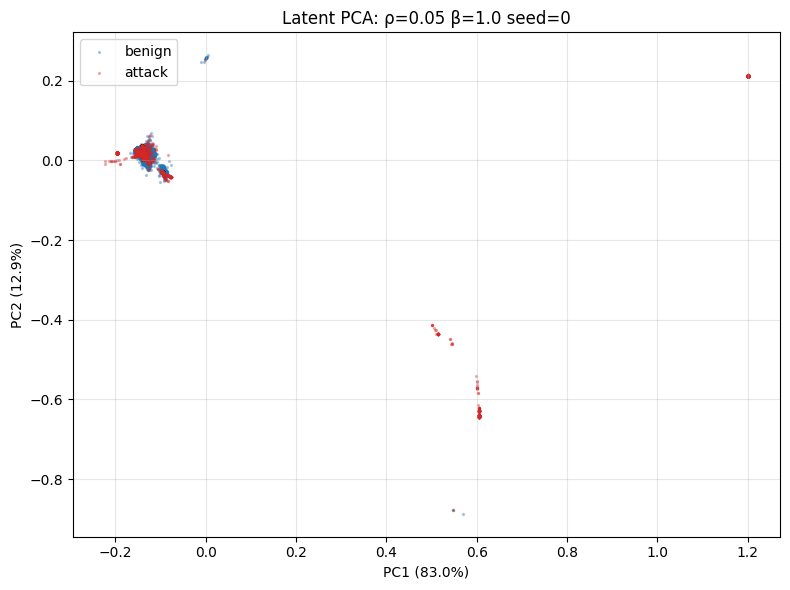

In [21]:
from sklearn.decomposition import PCA

FIG_DIR.mkdir(parents=True, exist_ok=True)
zv = np.load(Z_VAL, mmap_mode='r')
yv = np.load(Y_VAL_8)

rng = np.random.default_rng(0)
idx_b = np.where(yv == BASE['benign_label'])[0]
idx_a = np.where(yv != BASE['benign_label'])[0]
idx_b = rng.choice(idx_b, min(10_000, len(idx_b)), replace=False)
idx_a = rng.choice(idx_a, min(10_000, len(idx_a)), replace=False)

zb = np.asarray(zv[idx_b]); za = np.asarray(zv[idx_a])
pca = PCA(n_components=2, random_state=0)
Z2 = pca.fit_transform(np.vstack([zb, za]))

plt.figure(figsize=(8,6))
plt.scatter(Z2[:len(zb),0], Z2[:len(zb),1], s=2, alpha=0.3, label='benign', color='tab:blue')
plt.scatter(Z2[len(zb):,0], Z2[len(zb):,1], s=2, alpha=0.3, label='attack', color='tab:red')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(); plt.grid(alpha=.3)
plt.title(f'Latent PCA: ρ={top1["rho"]} β={top1["beta"]} seed=0')
plt.tight_layout()
out = FIG_DIR / '04_latent_pca.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

### Cell 20 — Final summary JSON

In [22]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
top1_row = grid_df[(grid_df['rho']==top1['rho']) & (grid_df['beta']==top1['beta'])].iloc[0]

final = {
    'week': 4,
    'timestamp': time.strftime('%Y-%m-%d %H:%M'),
    'model_params': int(grid_df['model_params'].iloc[0]),
    'grid': {
        'n_configs': len(grid_df),
        'best': {'rho': float(top1['rho']), 'beta': float(top1['beta']),
                 'auc': float(top1_row['auc_recon']),
                 'fpr_at_tpr95': float(top1_row['fpr_at_tpr95'])},
        'auc_range': [float(grid_df['auc_recon'].min()), float(grid_df['auc_recon'].max())],
    },
    'multiseed': {},
}
for _, r in agg.iterrows():
    key = f"rho={r['rho']}_beta={r['beta']}"
    final['multiseed'][key] = {
        'auc_mean': float(r['auc_mean']), 'auc_std': float(r['auc_std']),
        'fpr_mean': float(r['fpr_mean']), 'fpr_std': float(r['fpr_std']),
        'mse_mean': float(r['mse_mean']), 'mse_std': float(r['mse_std']),
        'n_seeds': 5,
    }

ff = RESULT_DIR / 'week4_final_summary.json'
with open(ff, 'w') as f:
    json.dump(final, f, indent=2)
print(f'✓ {ff}')
print(json.dumps(final, indent=2))

✓ /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_final_summary.json
{
  "week": 4,
  "timestamp": "2026-04-24 18:54",
  "model_params": 4374,
  "grid": {
    "n_configs": 12,
    "best": {
      "rho": 0.05,
      "beta": 1.0,
      "auc": 0.9958319593,
      "fpr_at_tpr95": 0.00418
    },
    "auc_range": [
      0.98897945775,
      0.9958319593
    ]
  },
  "multiseed": {
    "rho=0.05_beta=1.0": {
      "auc_mean": 0.9950963293400001,
      "auc_std": 0.0009129238274055573,
      "fpr_mean": 0.005312,
      "fpr_std": 0.0051689815244398,
      "mse_mean": 0.03168076268305513,
      "mse_std": 0.013692677525017752,
      "n_seeds": 5
    },
    "rho=0.1_beta=10.0": {
      "auc_mean": 0.99503997713,
      "auc_std": 0.0006964592072764066,
      "fpr_mean": 0.003938,
      "fpr_std": 0.00256173183608277,
      "mse_mean": 0.026852907898534444,
      "mse_std": 0.01196162224743975,
      "n_seeds": 5
    }
  }
}


### Cell 21 — Checklist Week 4

In [23]:
checklist = {
    'Grid CSV'        : GRID_CSV,
    'MS CSV'          : MS_CSV,
    'Top JSON'        : TOP_JSON,
    'Final JSON'      : RESULT_DIR / 'week4_final_summary.json',
    'Heatmap'         : FIG_DIR / '04_grid_heatmap.png',
    'LR curves'       : FIG_DIR / '04_learning_curves_top1.png',
    'Boxplot'         : FIG_DIR / '04_seed_boxplot.png',
    'PCA'             : FIG_DIR / '04_latent_pca.png',
    'z_benign'        : Z_BENIGN,
    'z_val'           : Z_VAL,
    'y_val_8'         : Y_VAL_8,
    'y_val_34'        : Y_VAL_34,
}
for seed in SEEDS:
    checklist[f'ckpt top-1 s={seed}'] = CKPT_DIR / f"sae_v1_rho={top1['rho']}_beta={top1['beta']}_seed={seed}_best.pt"

n = 0
for k, v in checklist.items():
    ok = v.exists()
    n += int(ok)
    print(f'{"✓" if ok else "✗"} {k:<20} {v}')
print(f'\n{n}/{len(checklist)} artifacts')
if n == len(checklist):
    print('\n🎉 WEEK 4 COMPLETE')

✓ Grid CSV             /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_grid_extended.csv
✓ MS CSV               /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_multiseed.csv
✓ Top JSON             /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_top_configs.json
✓ Final JSON           /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/week4_final_summary.json
✓ Heatmap              /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_grid_heatmap.png
✓ LR curves            /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_learning_curves_top1.png
✓ Boxplot              /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_seed_boxplot.png
✓ PCA                  /content/drive/MyDrive/sae-lof-ids-pi5/figs/week4/04_latent_pca.png
✓ z_benign             /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/z_benign_train_top1_seed0.npy
✓ z_val                /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/z_val_top1_seed0.npy
✓ y_val_8              

### Cell 22 — Week 5 preview

In [24]:
print('='*60)
print('WEEK 5 PLAN: LOF on latent z')
print('='*60)
print(f'Top-1: ρ={top1["rho"]} β={top1["beta"]}')
print(f'Inputs for Week 5:')
print(f'  z_benign_train: {np.load(Z_BENIGN, mmap_mode="r").shape}')
print(f'  z_val         : {np.load(Z_VAL, mmap_mode="r").shape}')
print(f'  y_val_8       : {np.load(Y_VAL_8).shape if Y_VAL_8.exists() else "N/A"}')
print(f'  y_val_34      : {np.load(Y_VAL_34).shape if Y_VAL_34.exists() else "N/A"}')
print()
print('Tasks:')
print('  1. Sample 100k benign → LOF ball_tree fit')
print('  2. Ablation k ∈ {10,20,50,100}')
print('  3. Threshold @ FPR=5% → TPR, F1-macro')
print('  4. Compare vs recon-MSE (Week 4 top-1 AUC)')

WEEK 5 PLAN: LOF on latent z
Top-1: ρ=0.05 β=1.0
Inputs for Week 5:
  z_benign_train: (878556, 8)
  z_val         : (4668658, 8)
  y_val_8       : (4668658,)
  y_val_34      : (4668658,)

Tasks:
  1. Sample 100k benign → LOF ball_tree fit
  2. Ablation k ∈ {10,20,50,100}
  3. Threshold @ FPR=5% → TPR, F1-macro
  4. Compare vs recon-MSE (Week 4 top-1 AUC)


# Chuan bi cho Week 5

In [29]:
# 1. Xác nhận shape và dtype của 4 file .npy
import numpy as np
from pathlib import Path

BASE = Path('/content/drive/MyDrive/sae-lof-ids-pi5/results/week4')
for name in ['z_benign_train_top1_seed0',
             'z_val_top1_seed0',
             'y_val_8class_top1_seed0',
             'y_val_34class_top1_seed0']:
    arr = np.load(BASE / f'{name}.npy', mmap_mode='r')
    print(f'{name:40s}  shape={arr.shape}  dtype={arr.dtype}')

z_benign_train_top1_seed0                 shape=(878556, 8)  dtype=float32
z_val_top1_seed0                          shape=(4668658, 8)  dtype=float32
y_val_8class_top1_seed0                   shape=(4668658,)  dtype=int8
y_val_34class_top1_seed0                  shape=(4668658,)  dtype=int8


In [30]:
# 2. Phân bố nhãn y_val (8-class và 34-class)
y8  = np.load(BASE / 'y_val_8class_top1_seed0.npy')
y34 = np.load(BASE / 'y_val_34class_top1_seed0.npy')

# 8-class
import pandas as pd
s8 = pd.Series(y8).value_counts().sort_index()
print('8-class:')
print(s8)
print(f'  benign label (0) count: {(y8==0).sum():,}')
print(f'  attack count          : {(y8!=0).sum():,}')

# 34-class
s34 = pd.Series(y34).value_counts().sort_index()
print('\n34-class (top 10 + bottom 5):')
print(s34.head(10))
print(s34.tail(5))
print(f'  classes with < 100 samples in val: {(s34 < 100).sum()}')

8-class:
0     109820
1       1307
2    3398456
3     809073
4     263412
5      35457
6      48650
7       2483
Name: count, dtype: int64
  benign label (0) count: 109,820
  attack count          : 4,558,838

34-class (top 10 + bottom 5):
0       322
1    109820
2       586
3       541
4     28511
5      2879
6    720050
7     45249
8    409476
9    404528
Name: count, dtype: int64
29    8229
30     525
31     125
32    3738
33     384
Name: count, dtype: int64
  classes with < 100 samples in val: 0


In [31]:
# 3. Statistics của z_benign_train để chọn strategy sampling cho LOF
z = np.load(BASE / 'z_benign_train_top1_seed0.npy')
print(f'shape: {z.shape}')
print(f'per-dim mean: {z.mean(axis=0)}')
print(f'per-dim std : {z.std(axis=0)}')
print(f'per-dim min : {z.min(axis=0)}')
print(f'per-dim max : {z.max(axis=0)}')
print(f'range overall: [{z.min():.4f}, {z.max():.4f}]')

# Check NaN/Inf
print(f'NaN: {np.isnan(z).any()}, Inf: {np.isinf(z).any()}')

# Dead dims: dimensions luôn gần 0 (không học được gì)?
dead_mask = z.std(axis=0) < 0.01
print(f'dead latent dims (std < 0.01): {dead_mask.sum()}/8')

shape: (878556, 8)
per-dim mean: [0.05011232 0.05027838 0.0502629  0.05014994 0.05043826 0.05005658
 0.05037231 0.05033946]
per-dim std : [0.02347918 0.039837   0.0094513  0.00841017 0.02713005 0.01419702
 0.02910342 0.00974271]
per-dim min : [0.00000000e+00 3.56002033e-18 1.24350959e-22 1.16944460e-29
 1.30442514e-11 1.02017356e-32 1.17702166e-06 1.00053861e-14]
per-dim max : [0.99633634 0.99999356 0.98126423 0.14090538 0.99999714 0.99965954
 1.         0.97562474]
range overall: [0.0000, 1.0000]
NaN: False, Inf: False
dead latent dims (std < 0.01): 3/8


In [28]:
# ============================================================
# WEEK 5 PRE-FLIGHT CHECK — validate Week 4 artifacts
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path('/content/drive/MyDrive/sae-lof-ids-pi5/results/week4')

# --- 1. Shape & dtype of 4 .npy files ---
print('=' * 70)
print('1. ARTIFACT SHAPES & DTYPES')
print('=' * 70)
files = {
    'z_benign_train': 'z_benign_train_top1_seed0.npy',
    'z_val'         : 'z_val_top1_seed0.npy',
    'y_val_8'       : 'y_val_8class_top1_seed0.npy',
    'y_val_34'      : 'y_val_34class_top1_seed0.npy',
}
arrays = {}
for name, fn in files.items():
    p = BASE / fn
    if not p.exists():
        print(f'  ✗ MISSING: {p}')
        continue
    arr = np.load(p, mmap_mode='r')
    arrays[name] = arr
    size_mb = p.stat().st_size / 1e6
    print(f'  ✓ {name:18s}  shape={str(arr.shape):20s}  dtype={arr.dtype!s:10s}  file={size_mb:.1f}MB')

# --- 2. Label distribution (8-class & 34-class) ---
print()
print('=' * 70)
print('2. LABEL DISTRIBUTION')
print('=' * 70)
y8  = np.asarray(arrays['y_val_8'])
y34 = np.asarray(arrays['y_val_34'])

print('\n-- 8-class --')
s8 = pd.Series(y8).value_counts().sort_index()
print(s8.to_string())
print(f'\n  unique labels    : {sorted(s8.index.tolist())}')
print(f'  label==0 count   : {(y8==0).sum():,}')
print(f'  label!=0 count   : {(y8!=0).sum():,}')
print(f'  total            : {len(y8):,}')

print('\n-- 34-class --')
s34 = pd.Series(y34).value_counts().sort_index()
print(f'  num unique       : {s34.size}')
print(f'\n  top 5 largest    :')
print(s34.nlargest(5).to_string())
print(f'\n  bottom 5 smallest:')
print(s34.nsmallest(5).to_string())
print(f'\n  classes with <100 samples in val: {(s34 < 100).sum()}')
print(f'  classes with <10  samples in val: {(s34 < 10).sum()}')
print(f'  classes with ==0  samples in val: {(s34 == 0).sum()}  (expected 0 — shouldn\'t happen)')

# --- 3. Statistics of z_benign_train ---
print()
print('=' * 70)
print('3. LATENT Z STATISTICS (z_benign_train)')
print('=' * 70)
# Load into RAM since we need to compute stats (878k × 8 × 4B ≈ 28 MB — trivial)
z = np.asarray(arrays['z_benign_train'], dtype=np.float32)
print(f'  shape: {z.shape}, dtype: {z.dtype}')
print(f'  overall range: [{z.min():.6f}, {z.max():.6f}]')
print(f'  NaN present  : {np.isnan(z).any()}')
print(f'  Inf present  : {np.isinf(z).any()}')
print()
print(f'  per-dim statistics:')
print(f'  {"dim":<5}{"mean":>10}{"std":>10}{"min":>10}{"max":>10}  note')
for d in range(z.shape[1]):
    col = z[:, d]
    m, s, lo, hi = col.mean(), col.std(), col.min(), col.max()
    note = ''
    if s < 0.01:
        note = 'DEAD (std<0.01)'
    elif s < 0.05:
        note = 'low-variance'
    elif lo > 0.99 or hi < 0.01:
        note = 'saturated'
    print(f'  {d:<5}{m:>10.4f}{s:>10.4f}{lo:>10.4f}{hi:>10.4f}  {note}')

# Same for z_val sample (check distribution drift)
print(f'\n  z_val overall range: [{arrays["z_val"].min():.4f}, {arrays["z_val"].max():.4f}]')

print()
print('=' * 70)
print('PRE-FLIGHT CHECK COMPLETE — paste all output above to continue Week 5')
print('=' * 70)

1. ARTIFACT SHAPES & DTYPES
  ✓ z_benign_train      shape=(878556, 8)           dtype=float32     file=28.1MB
  ✓ z_val               shape=(4668658, 8)          dtype=float32     file=149.4MB
  ✓ y_val_8             shape=(4668658,)            dtype=int8        file=4.7MB
  ✓ y_val_34            shape=(4668658,)            dtype=int8        file=4.7MB

2. LABEL DISTRIBUTION

-- 8-class --
0     109820
1       1307
2    3398456
3     809073
4     263412
5      35457
6      48650
7       2483

  unique labels    : [0, 1, 2, 3, 4, 5, 6, 7]
  label==0 count   : 109,820
  label!=0 count   : 4,558,838
  total            : 4,668,658

-- 34-class --
  num unique       : 34

  top 5 largest    :
6     720050
14    541228
13    449767
8     409476
10    405919

  bottom 5 smallest:
31    125
28    226
0     322
33    384
30    525

  classes with <100 samples in val: 0
  classes with <10  samples in val: 0
  classes with ==0  samples in val: 0  (expected 0 — shouldn't happen)

3. LATENT Z STATI